Train shape: (541292, 155)
Insurers: ['Insurer_A', 'Insurer_B', 'Insurer_C', 'Insurer_D', 'Insurer_E', 'Insurer_F', 'Insurer_G', 'Insurer_H', 'Insurer_I', 'Insurer_J', 'Insurer_K']
['quote_id', 'vehicle_ownership_duration', 'vehicle_number_plate', 'coverage', 'claim_free_years', 'payment_frequency', 'contractor_birthdate', 'is_driver_owner', 'usage', 'second_driver_birthdate', 'second_driver_claim_free_years', 'vehicle_maker', 'vehicle_model', 'vehicle_fuel_type', 'vehicle_engine_size', 'vehicle_power', 'vehicle_net_weight', 'vehicle_gross_weight', 'vehicle_length', 'vehicle_width', 'vehicle_height', 'vehicle_number_of_cylinders', 'vehicle_number_of_doors', 'vehicle_number_of_seats', 'vehicle_number_of_wheels', 'vehicle_primary_color', 'vehicle_value_new', 'vehicle_net_max_power', 'vehicle_net_max_power_electric', 'vehicle_nominal_continuous_max_power', 'vehicle_power_to_net_weight_ratio', 'vehicle_age', 'vehicle_first_registration_date', 'vehicle_country_first_registration_date', 'veh

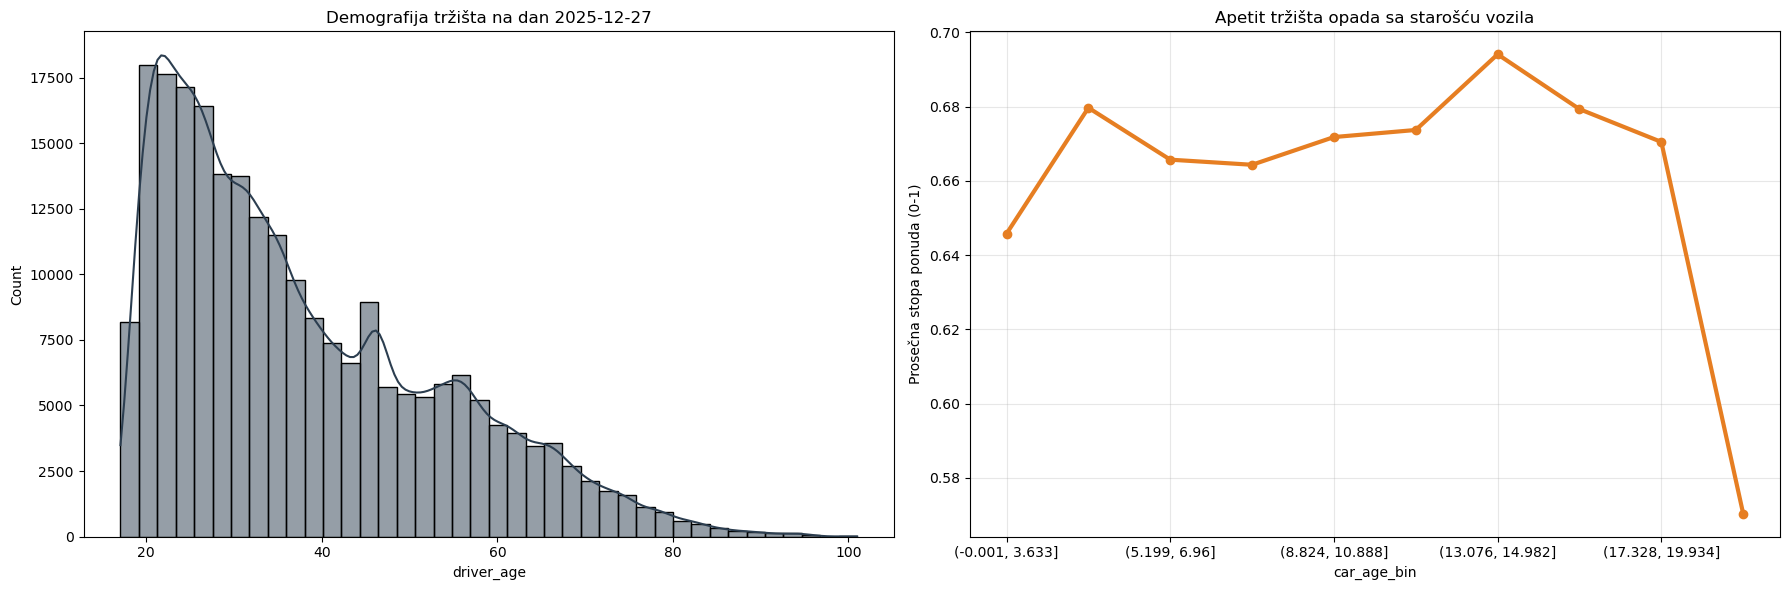

Procenat taxi vozila: 0.00%
Postotak oldtimera (>30 god): 0.33%
Minimalna starost vozača u podacima: 17.1


In [42]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

train_raw = pd.read_parquet('datasets/block1_train.parquet', engine='fastparquet')


insurer_cols = [c for c in train_raw.columns if c.endswith('_price')]
insurers = [c.replace('_price', '') for c in insurer_cols]

print(f"Train shape: {train_raw.shape}")
print(f"Insurers: {insurers}")

print(train_raw.columns.tolist())

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Liste kolona (iz tvojih podataka)
insurer_cols = [f'Insurer_{c}_price' for c in 'ABCDEFGHIJK']
deduct_cols = [f'Insurer_{c}_deductible' for c in 'ABCDEFGHIJK']

def senior_data_alignment_fixed(df):
    print("--- ZAPOČINJEM SENIORSKU VALIDACIJU PODATAKA ---")
    
    # 1. Dinamičko sidro (Anchor Date)
    # Gledamo najkasniji datum prve registracije u svetu kao reper
    temp_reg_date = pd.to_datetime(df['vehicle_first_registration_date'], errors='coerce')
    anchor_date = temp_reg_date.max()
    print(f"[INFO] Analitičko sidro (Market Snapshot): {anchor_date.date()}")

    # 2. Masovna numerička konverzija (Rizik faktori)
    numeric_targets = insurer_cols + deduct_cols + [
        'claim_free_years', 'vehicle_value_new', 'vehicle_power', 'vehicle_engine_size',
        'municipality_crimes_per_1000', 'vehicle_planned_annual_mileage'
    ]
    
    for col in numeric_targets:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    # 3. Feature Engineering: Starost (Age)
    df['contractor_birthdate'] = pd.to_datetime(df['contractor_birthdate'], errors='coerce')
    df['vehicle_first_registration_date'] = temp_reg_date
    
    # driver_age i car_age na dan sidra
    df['driver_age'] = (anchor_date - df['contractor_birthdate']).dt.days / 365.25
    df['car_age'] = (anchor_date - df['vehicle_first_registration_date']).dt.days / 365.25

    # 4. Taxi detekcija (Binarni rizik)
    if 'vehicle_is_taxi' in df.columns:
        # Često je u podacima 'yes'/'no', 1/0 ili True/False
        df['is_taxi'] = df['vehicle_is_taxi'].map({'yes': 1, 'no': 0, True: 1, False: 0}).fillna(0)

    # 5. Seniorski Outlier Filter (Logička provera)
    # Vozač ne može biti mlađi od 17 (u većini zemalja EU za osiguranje na svoje ime)
    df.loc[df['driver_age'] < 17, 'driver_age'] = np.nan
    # Auto stariji od 50 godina tretiramo kao oldtimer (drugačija pravila)
    df['is_oldtimer'] = (df['car_age'] > 30).astype(int)

    return df, anchor_date

# Izvršavanje
train_raw, market_anchor = senior_data_alignment_fixed(train_raw)

# --- VIZUELIZACIJA (ISPRAVLJENA) ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafik A: Demografija
sns.histplot(train_raw['driver_age'].dropna(), bins=40, kde=True, ax=axes[0], color='#2c3e50')
axes[0].set_title(f'Demografija tržišta na dan {market_anchor.date()}')

# Grafik B: Market Appetite (Seniorski fix za GroupBy)
# 1. Kreiramo privremenu kolonu prisutnosti
presence_matrix = train_raw[insurer_cols].notnull()
# 2. Binujemo starost vozila na 10 jednakih delova (decili)
train_raw['car_age_bin'] = pd.qcut(train_raw['car_age'].dropna(), 10)
# 3. Spajamo i grupisanje
coverage_by_age = presence_matrix.groupby(train_raw['car_age_bin'], observed=True).mean().mean(axis=1)

coverage_by_age.plot(kind='line', marker='o', ax=axes[1], color='#e67e22', linewidth=3)
axes[1].set_title('Apetit tržišta opada sa starošću vozila')
axes[1].set_ylabel('Prosečna stopa ponuda (0-1)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --- ANALITIČKI OUTPUT ---
print(f"Procenat taxi vozila: {train_raw['is_taxi'].mean()*100:.2f}%")
print(f"Postotak oldtimera (>30 god): {train_raw['is_oldtimer'].mean()*100:.2f}%")
print(f"Minimalna starost vozača u podacima: {train_raw['driver_age'].min():.1f}")




=== VREMENSKI AUDIT (Anchor Verification) ===
First Reg Global     : 2025-12-27
Last Reg Market      : 2025-12-27
Inspection Date      : 2025-12-12

PREPORUČENO KONAČNO SIDRO: 2025-12-27


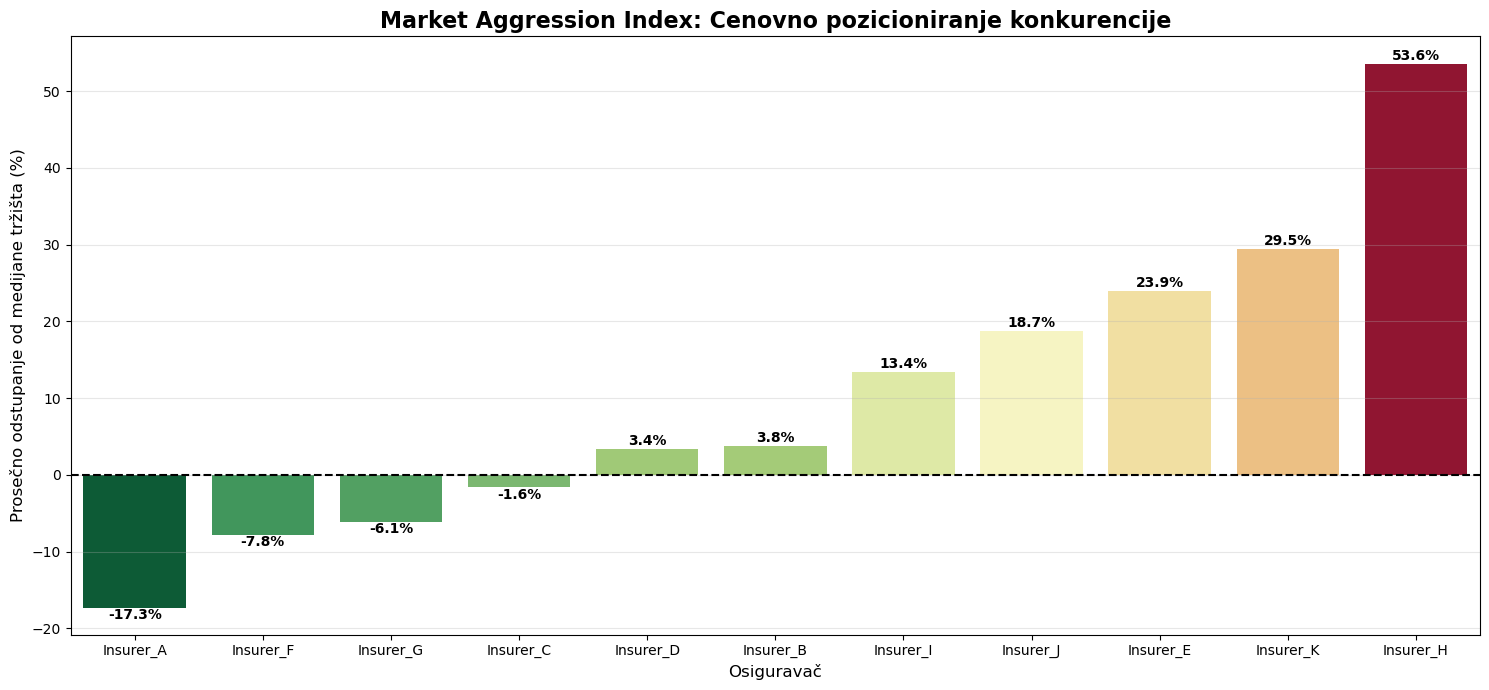

=== STRATEŠKA SEGMENTACIJA KONKURENATA ===
LIDER NISKIH CENA (Discount King): Insurer_A (-17.3%)
PREMIUM IGRAČ (High Margin):       Insurer_H (53.6%)
----------------------------------------
Distribucija agresivnosti (Opisno):
count    11.000000
mean     10.311595
std      20.241697
min     -17.284139
25%      -3.868206
50%       3.795029
75%      21.312139
max      53.587016
dtype: float64
                                    Missing %  Unique Values  Zero Values %
vehicle_value_new                    0.504164          55108       0.000000
claim_free_years                     0.000000             76      29.453419
municipality_crimes_per_1000         2.898251            594       0.000000
driver_age                          57.325621           9479       0.000000
car_age                              0.274898           9586       0.000185
postal_code_average_property_value  11.855154           1272       0.000000


In [43]:
# Provera maksimalnih vrednosti za sve relevantne datume
audit_dates = {
    'First Reg Global': pd.to_datetime(train_raw['vehicle_first_registration_date']).max(),
    'Last Reg Market': pd.to_datetime(train_raw['vehicle_last_registration_date'], errors='coerce').max(),
    'Inspection Date': pd.to_datetime(train_raw['vehicle_inspection_report_date'], errors='coerce').max()
}

print("=== VREMENSKI AUDIT (Anchor Verification) ===")
for label, d in audit_dates.items():
    print(f"{label:20} : {d.date() if pd.notnull(d) else 'N/A'}")

# Ako je Last Reg Market npr. mart 2026, onda pomeramo sidro!
new_anchor = max([d for d in audit_dates.values() if pd.notnull(d)])
print(f"\nPREPORUČENO KONAČNO SIDRO: {new_anchor.date()}")

# 1. Definisanje osiguravača (ako već nisu definisani)
insurer_cols = [f'Insurer_{c}_price' for c in 'ABCDEFGHIJK']

# 2. Računamo medijanu tržišta po svakom profilu (vrlo robusno na outliere)
train_raw['market_median'] = train_raw[insurer_cols].median(axis=1)

# 3. Računamo procentualno odstupanje svakog osiguravača od te medijane
diff_cols = []
for ins in insurer_cols:
    diff_col_name = f'{ins}_diff_pct'
    # Formula: ((Moja_Cena - Medijana) / Medijana) * 100
    train_raw[diff_col_name] = ((train_raw[ins] - train_raw['market_median']) / train_raw['market_median']) * 100
    diff_cols.append(diff_col_name)

# 4. Agregacija: Srednja vrednost agresivnosti
aggression_report = train_raw[diff_cols].mean().sort_values()
aggression_report.index = [i.replace('_price_diff_pct', '').replace('_diff_pct', '') for i in aggression_report.index]

# 5. Vizuelizacija: Ranking agresivnosti
plt.figure(figsize=(15, 7))
# Koristimo Diverging paletu (Zeleno za jeftine, Crveno za skupe)
norm = plt.Normalize(aggression_report.min(), aggression_report.max())
colors = plt.cm.RdYlGn_r(norm(aggression_report.values))

sns.barplot(x=aggression_report.index, y=aggression_report.values, palette=list(colors))

plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('Market Aggression Index: Cenovno pozicioniranje konkurencije', fontsize=16, fontweight='bold')
plt.ylabel('Prosečno odstupanje od medijane tržišta (%)', fontsize=12)
plt.xlabel('Osiguravač', fontsize=12)

# Dodavanje labela na barove
for i, v in enumerate(aggression_report.values):
    plt.text(i, v + (0.5 if v > 0 else -1.5), f"{v:.1f}%", ha='center', fontweight='bold', 
             color='black', fontsize=10)

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# --- SENIORSKI OUTPUT ZA TVOJU ANALIZU ---
print("=== STRATEŠKA SEGMENTACIJA KONKURENATA ===")
print(f"LIDER NISKIH CENA (Discount King): {aggression_report.index[0]} ({aggression_report.iloc[0]:.1f}%)")
print(f"PREMIUM IGRAČ (High Margin):       {aggression_report.index[-1]} ({aggression_report.iloc[-1]:.1f}%)")
print("-" * 40)
print("Distribucija agresivnosti (Opisno):")
print(aggression_report.describe())

def senior_integrity_audit(df):
    # Proveravamo samo "High-Impact" kolone za Task 2
    critical_cols = [
        'vehicle_value_new', 'claim_free_years', 'municipality_crimes_per_1000',
        'driver_age', 'car_age', 'postal_code_average_property_value'
    ]
    
    audit = pd.DataFrame({
        'Missing %': df[critical_cols].isnull().mean() * 100,
        'Unique Values': df[critical_cols].nunique(),
        'Zero Values %': (df[critical_cols] == 0).mean() * 100
    })
    
    return audit

print(senior_integrity_audit(train_raw))

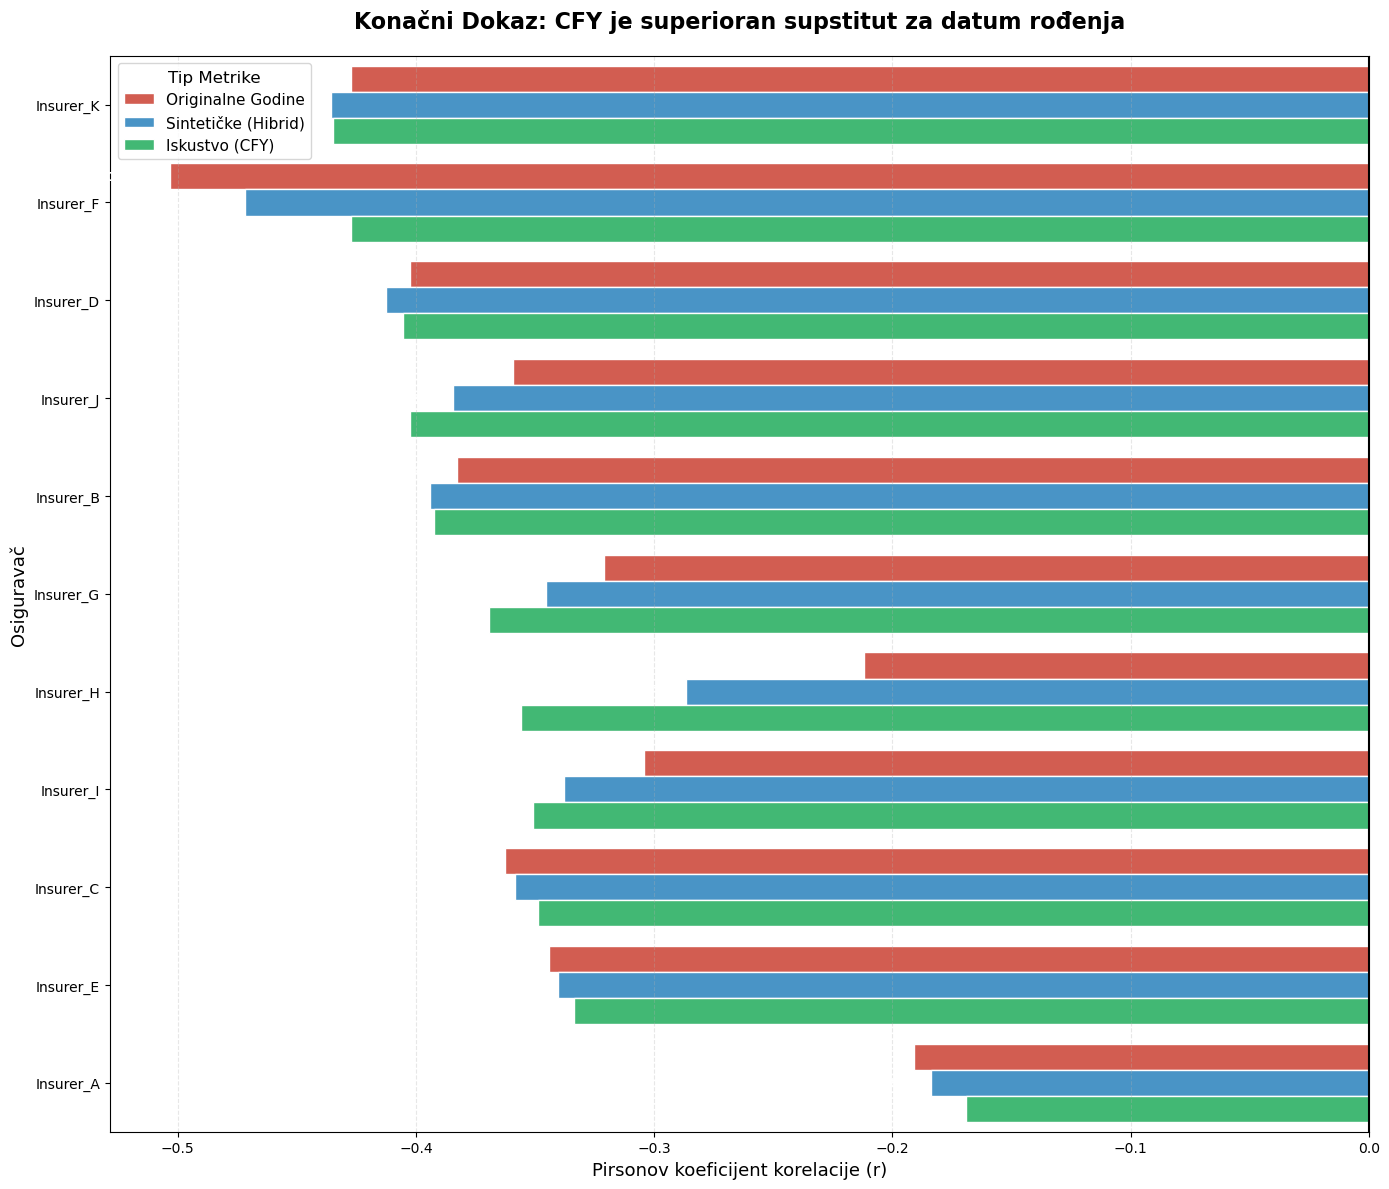

------------------------------
PROSEČNE VREDNOSTI (KONAČNA PROVERA):
Type
Iskustvo (CFY)        -0.362759
Sintetičke (Hibrid)   -0.359247
Originalne Godine     -0.346403
Name: r, dtype: float64
------------------------------


In [48]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- PAMETNA KORELACIJA: KONAČNI FIX ZA BOJE (SEABORN) ---

# 1. Priprema maski i mapa (bez menjanja train_raw)
mask_has_age = train_raw['contractor_birthdate'].notnull()
age_experience_map = train_raw[mask_has_age].groupby('claim_free_years')['driver_age'].mean()

# 2. Kreiranje sintetičkog niza (u memoriji)
synthetic_age = train_raw['driver_age'].fillna(
    train_raw['claim_free_years'].map(age_experience_map)
)

# 3. Obračun korelacija
correlations = []
for ins in insurer_cols:
    valid_mask = train_raw[ins].notnull()
    
    # Računamo korelacije
    corr_orig = train_raw[valid_mask & mask_has_age][[ins, 'driver_age']].corr().iloc[0,1]
    corr_synth = pd.concat([train_raw[ins], synthetic_age], axis=1).corr().iloc[0,1]
    corr_exp = train_raw[valid_mask][[ins, 'claim_free_years']].corr().iloc[0,1]
    
    # Skladištimo podatke u 'dugačkom' formatu (long format) idealnom za Seaborn
    # Svaki red je jedna korelacija
    correlations.append({'Insurer': ins.replace('_price', ''), 'Type': 'Originalne Godine', 'r': corr_orig})
    correlations.append({'Insurer': ins.replace('_price', ''), 'Type': 'Sintetičke (Hibrid)', 'r': corr_synth})
    correlations.append({'Insurer': ins.replace('_price', ''), 'Type': 'Iskustvo (CFY)', 'r': corr_exp})

# Prebacujemo u DataFrame
corr_long_df = pd.DataFrame(correlations)

# 4. Definisanje FIKSNIH i eksplicitnih boja
my_palette = {
    'Originalne Godine': '#e74c3c',   # Crvena
    'Sintetičke (Hibrid)': '#3498db',  # Plava
    'Iskustvo (CFY)': '#2ecc71'      # Zelena
}

# 5. VIZUELIZACIJA (Preko Seaborn-a)
plt.figure(figsize=(14, 12))

# Prvo sortiramo osiguravače po jačini korelacije iskustva
# (Izvlačimo redosled iz originalnog obračuna)
insurer_order = corr_long_df[corr_long_df['Type'] == 'Iskustvo (CFY)'].sort_values(by='r')['Insurer'].tolist()

# Seaborn barplot garantuje mapiranje boja preko 'hue' parametra
ax = sns.barplot(
    data=corr_long_df,
    y='Insurer',
    x='r',
    hue='Type',
    palette=my_palette,       # Eksplicitna paleta
    hue_order=['Originalne Godine', 'Sintetičke (Hibrid)', 'Iskustvo (CFY)'], # Fix redosleda u legendi
    order=insurer_order,     # Fix redosleda osiguravača
    orient='h',
    edgecolor='white',
    linewidth=1
)

# Estetika
plt.title('Konačni Dokaz: CFY je superioran supstitut za datum rođenja', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Pirsonov koeficijent korelacije (r)', fontsize=13)
plt.ylabel('Osiguravač', fontsize=13)
plt.axvline(0, color='black', lw=1.5)
plt.grid(axis='x', alpha=0.3, linestyle='--')

# Postavljanje legende
plt.legend(title='Tip Metrike', fontsize=11, title_fontsize=12)

# Dodavanje vrednosti na barove (opciono, ali super za analizu)
for p in ax.patches:
    width = p.get_width()
    if width < -0.1: # Pišemo samo ako je bar dovoljno dugačak
        ax.text(width - 0.01, p.get_y() + p.get_height() / 2,
                f'{width:.3f}',
                ha="right", va="center", fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.show()

# --- FINALNA STATISTIKA ---
print("-" * 30)
print("PROSEČNE VREDNOSTI (KONAČNA PROVERA):")
print(corr_long_df.groupby('Type')['r'].mean().sort_values())
print("-" * 30)

In [52]:
print(train_raw['driver_age'].dtype)
print(train_raw['vehicle_value_new'].dtype)
print(train_raw['municipality_crimes_per_1000'].dtype)

float64
float64
float64


In [54]:
# ============================================================
# ĆELIJA 1 — Setup (pokreni ovo jednom)
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Učitaj
train_raw = pd.read_parquet('datasets/block1_train.parquet', engine='fastparquet')
insurer_cols = [f'Insurer_{c}_price' for c in 'ABCDEFGHIJK']
insurers = [c.replace('_price', '') for c in insurer_cols]

# Radni dataframe
df = train_raw.copy()

# Konverzije koje još nisu urađene
ref_date = pd.Timestamp('2025-12-27')
df['contractor_birthdate'] = pd.to_datetime(df['contractor_birthdate'], errors='coerce')
df['vehicle_first_registration_date'] = pd.to_datetime(
    df['vehicle_first_registration_date'], errors='coerce')

# Izvedene kolone
df['driver_age']       = (ref_date - df['contractor_birthdate']).dt.days / 365.25
df['vehicle_age_calc'] = (ref_date - df['vehicle_first_registration_date']).dt.days / 365.25
df['claim_free_years'] = pd.to_numeric(df['claim_free_years'], errors='coerce')
# Ensure vehicle_value_new is numeric before binning (fix TypeError in pd.cut when values are mixed types)
if 'vehicle_value_new' in df.columns:
    df['vehicle_value_new'] = pd.to_numeric(df['vehicle_value_new'], errors='coerce')
df['is_bad_driver']    = (df['claim_free_years'] < 0).astype(int)
df['num_quotes']       = df[insurer_cols].notnull().sum(axis=1)
df['market_median']    = df[insurer_cols].median(axis=1)

# Grupe
df['age_group'] = pd.cut(
    df['driver_age'],
    bins=[0, 25, 35, 45, 55, 65, 120],
    labels=['<25', '25-35', '35-45', '45-55', '55-65', '65+']
)
df['vehicle_value_group'] = pd.cut(
    df['vehicle_value_new'],
    bins=[0, 10000, 20000, 35000, 50000, 75000, 999999],
    labels=['<10k', '10-20k', '20-35k', '35-50k', '50-75k', '75k+']
)
df['vehicle_age_group'] = pd.cut(
    df['vehicle_age_calc'],
    bins=[0, 3, 7, 12, 20, 100],
    labels=['0-3g', '3-7g', '7-12g', '12-20g', '20g+']
)

# Style
sns.set_theme(style='whitegrid', font_scale=1.1)
print("✅ Setup gotov")
print(f"Shape: {df.shape}")

✅ Setup gotov
Shape: (541292, 163)


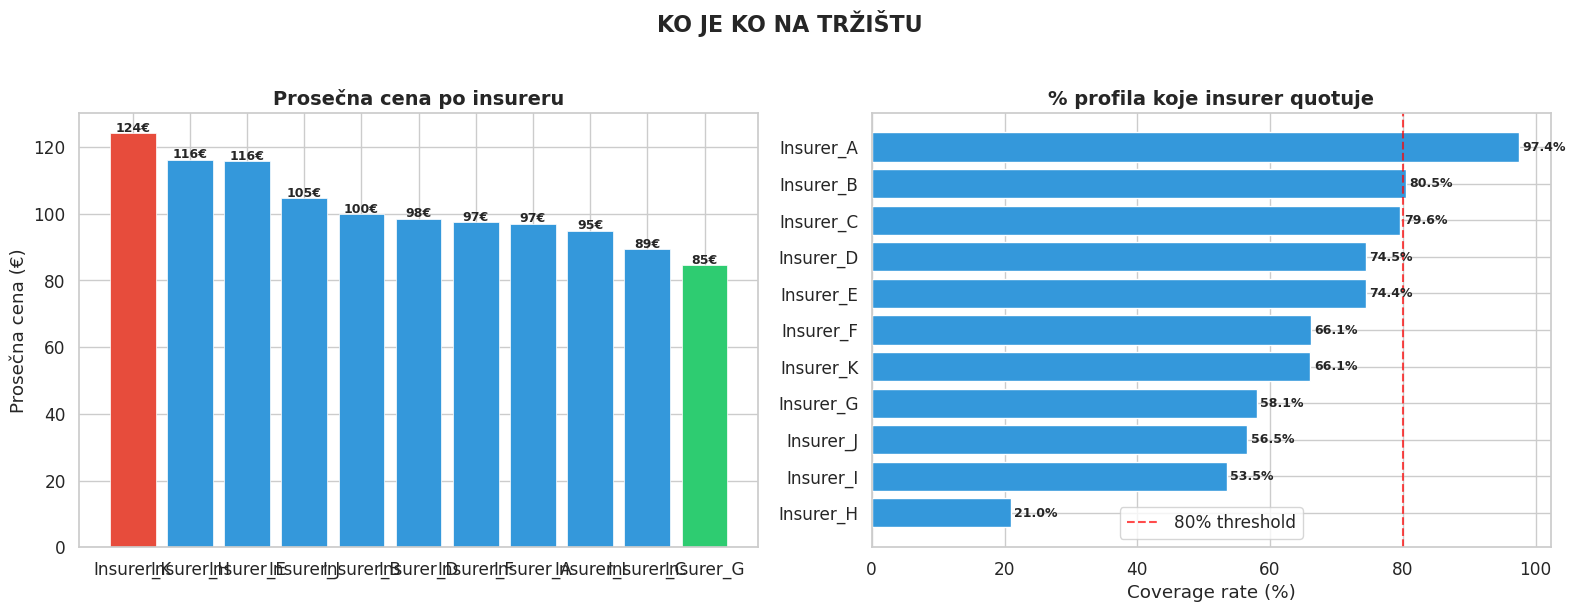

=== ANALIZA 1 — REZULTATI ===
Najskuplji:      Insurer_K — 124€
Najjeftiniji:    Insurer_G — 85€
Pricing spread:  47% razlika

Najselektivniji: Insurer_H — 21.0% profila
Najotvoreniji:   Insurer_A — 97.4% profila


In [55]:
# ============================================================
# ANALIZA 1 — Pricing overview + selektivnost
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Grafik 1: Prosečna cena ---
mean_prices = df[insurer_cols].mean().sort_values(ascending=False)
labels = [x.replace('_price', '') for x in mean_prices.index]
colors = ['#e74c3c' if i == 0 else '#2ecc71' if i == len(mean_prices)-1
          else '#3498db' for i in range(len(mean_prices))]

axes[0].bar(labels, mean_prices.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Prosečna cena po insureru', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Prosečna cena (€)')
for i, v in enumerate(mean_prices.values):
    axes[0].text(i, v + 0.5, f'{v:.0f}€', ha='center', fontsize=9, fontweight='bold')

# --- Grafik 2: Coverage rate ---
coverage_rate = (df[insurer_cols].notnull().sum() / len(df) * 100).sort_values()
labels2 = [x.replace('_price', '') for x in coverage_rate.index]

axes[1].barh(labels2, coverage_rate.values, color='#3498db', edgecolor='white')
axes[1].axvline(x=80, color='red', linestyle='--', alpha=0.7, label='80% threshold')
axes[1].set_title('% profila koje insurer quotuje', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Coverage rate (%)')
axes[1].legend()
for i, v in enumerate(coverage_rate.values):
    axes[1].text(v + 0.5, i, f'{v:.1f}%', va='center', fontsize=9, fontweight='bold')

plt.suptitle('KO JE KO NA TRŽIŠTU', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('01_ko_je_ko.png', dpi=150, bbox_inches='tight')
plt.show()

# Print
print("=== ANALIZA 1 — REZULTATI ===")
print(f"Najskuplji:      {mean_prices.index[0].replace('_price','')} — {mean_prices.iloc[0]:.0f}€")
print(f"Najjeftiniji:    {mean_prices.index[-1].replace('_price','')} — {mean_prices.iloc[-1]:.0f}€")
print(f"Pricing spread:  {(mean_prices.iloc[0]/mean_prices.iloc[-1]-1)*100:.0f}% razlika")
print(f"\nNajselektivniji: {coverage_rate.index[0].replace('_price','')} — {coverage_rate.iloc[0]:.1f}% profila")
print(f"Najotvoreniji:   {coverage_rate.index[-1].replace('_price','')} — {coverage_rate.iloc[-1]:.1f}% profila")

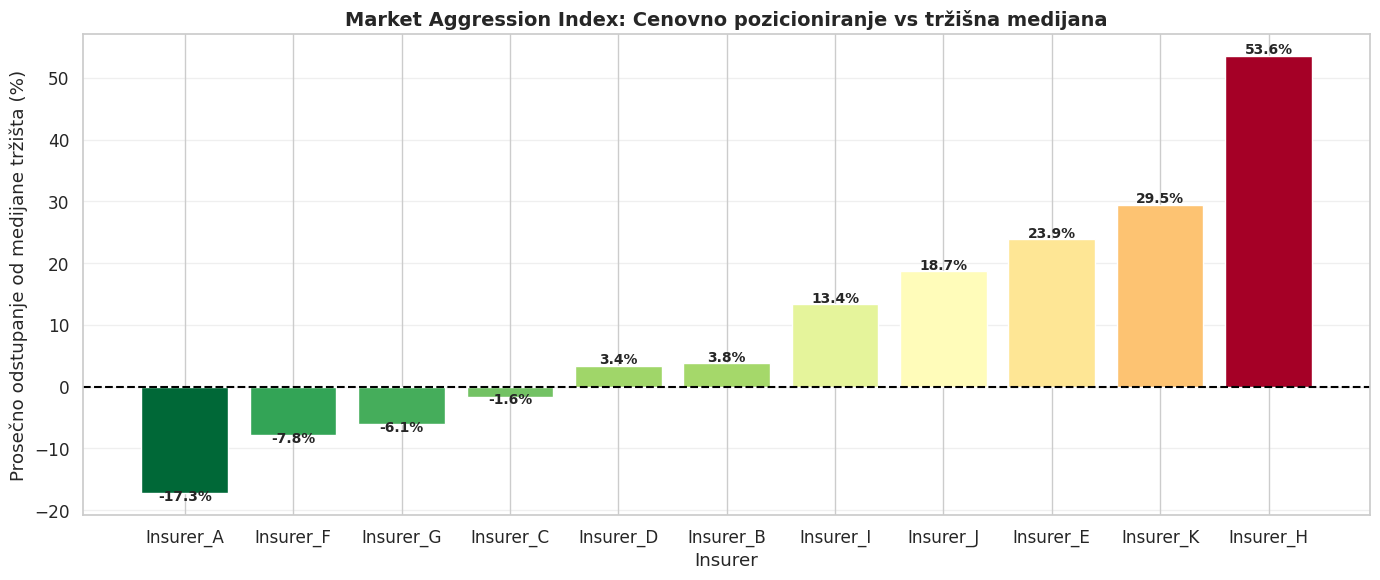

=== ANALIZA 2 — REZULTATI ===
Discount King:  Insurer_A (-17.3% ispod medijane)
Premium Player: Insurer_H (53.6% iznad medijane)

Svi insureri:
Insurer_A   -17.3
Insurer_F    -7.8
Insurer_G    -6.1
Insurer_C    -1.6
Insurer_D     3.4
Insurer_B     3.8
Insurer_I    13.4
Insurer_J    18.7
Insurer_E    23.9
Insurer_K    29.5
Insurer_H    53.6
dtype: float64


In [56]:
# ============================================================
# ANALIZA 2 — Market Aggression Index
# ============================================================
for ins in insurer_cols:
    df[f'{ins}_diff_pct'] = (
        (df[ins] - df['market_median']) / df['market_median']) * 100

diff_cols = [f'{ins}_diff_pct' for ins in insurer_cols]
aggression = df[diff_cols].mean().sort_values()
aggression.index = [i.replace('_price_diff_pct', '') for i in aggression.index]

plt.figure(figsize=(14, 6))
norm = plt.Normalize(aggression.min(), aggression.max())
colors = plt.cm.RdYlGn_r(norm(aggression.values))
bars = plt.bar(aggression.index, aggression.values, color=colors, edgecolor='white')
plt.axhline(0, color='black', linewidth=1.5, linestyle='--')
plt.title('Market Aggression Index: Cenovno pozicioniranje vs tržišna medijana',
          fontsize=14, fontweight='bold')
plt.ylabel('Prosečno odstupanje od medijane tržišta (%)')
plt.xlabel('Insurer')
for i, v in enumerate(aggression.values):
    plt.text(i, v + (0.3 if v >= 0 else -1.2),
             f'{v:.1f}%', ha='center', fontweight='bold', fontsize=10)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('02_aggression_index.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 2 — REZULTATI ===")
print(f"Discount King:  {aggression.index[0]} ({aggression.iloc[0]:.1f}% ispod medijane)")
print(f"Premium Player: {aggression.index[-1]} ({aggression.iloc[-1]:.1f}% iznad medijane)")
print(f"\nSvi insureri:")
print(aggression.round(1))

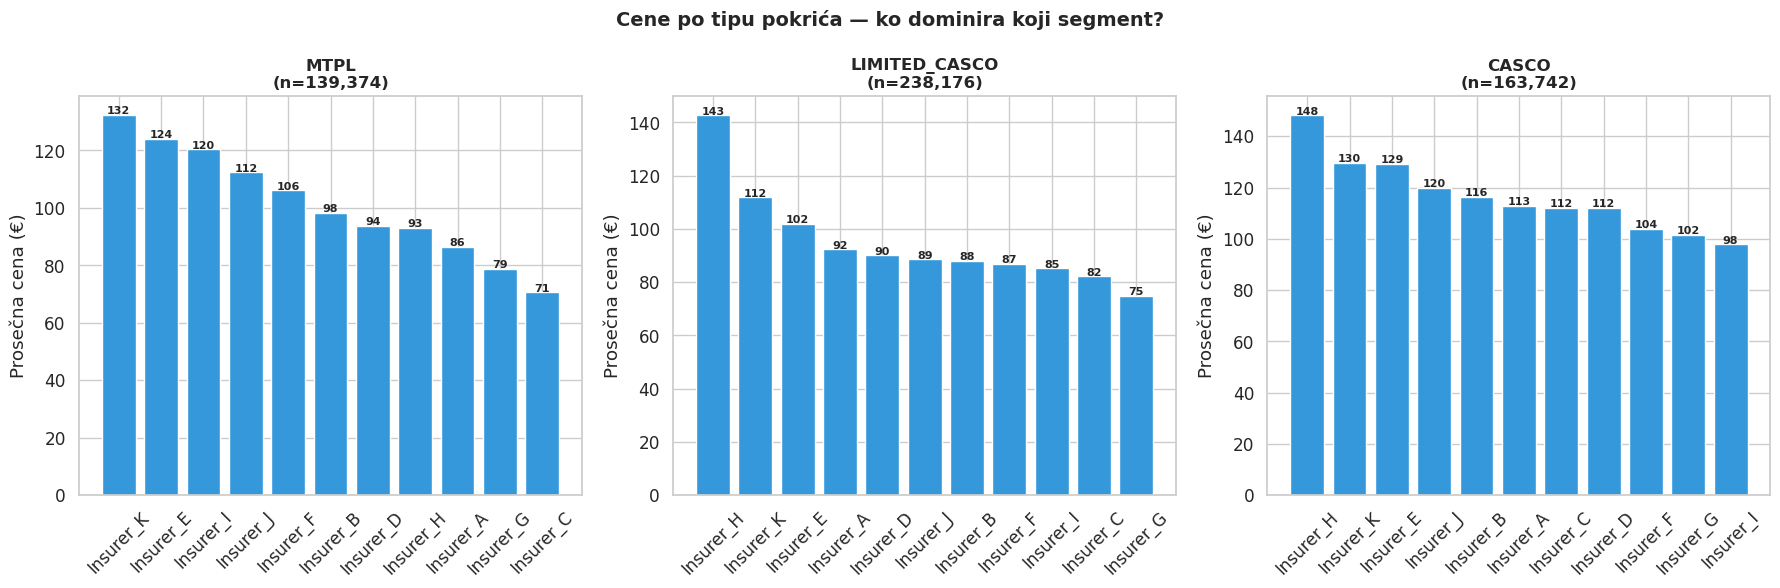

=== ANALIZA 3 — REZULTATI ===
mtpl            → najjeftiniji: Insurer_C (71€) | najskuplji: Insurer_K (132€)
mtpl            → najjeftiniji: Insurer_C (71€) | najskuplji: Insurer_K (132€)
limited_casco   → najjeftiniji: Insurer_G (75€) | najskuplji: Insurer_H (143€)
limited_casco   → najjeftiniji: Insurer_G (75€) | najskuplji: Insurer_H (143€)
casco           → najjeftiniji: Insurer_I (98€) | najskuplji: Insurer_H (148€)
casco           → najjeftiniji: Insurer_I (98€) | najskuplji: Insurer_H (148€)


In [57]:
# ============================================================
# ANALIZA 3 — Cene po coverage tipu
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
coverage_types = ['mtpl', 'limited_casco', 'casco']

for ax, cov in zip(axes, coverage_types):
    subset = df[df['coverage'] == cov]
    means = subset[insurer_cols].mean().sort_values(ascending=False)
    labels = [x.replace('_price', '') for x in means.index]
    ax.bar(labels, means.values, color='#3498db', edgecolor='white')
    ax.set_title(f'{cov.upper()}\n(n={len(subset):,})', fontsize=12, fontweight='bold')
    ax.set_ylabel('Prosečna cena (€)')
    ax.tick_params(axis='x', rotation=45)
    for i, (idx, val) in enumerate(means.items()):
        ax.text(i, val + 0.3, f'{val:.0f}', ha='center', fontsize=8, fontweight='bold')

plt.suptitle('Cene po tipu pokrića — ko dominira koji segment?',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('03_coverage_prices.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 3 — REZULTATI ===")
for cov in coverage_types:
    subset = df[df['coverage'] == cov]
    means = subset[insurer_cols].mean()
    cheapest = means.idxmin().replace('_price', '')
    priciest = means.idxmax().replace('_price', '')
    print(f"{cov:15} → najjeftiniji: {cheapest} ({means.min():.0f}€) | "
          f"najskuplji: {priciest} ({means.max():.0f}€)")

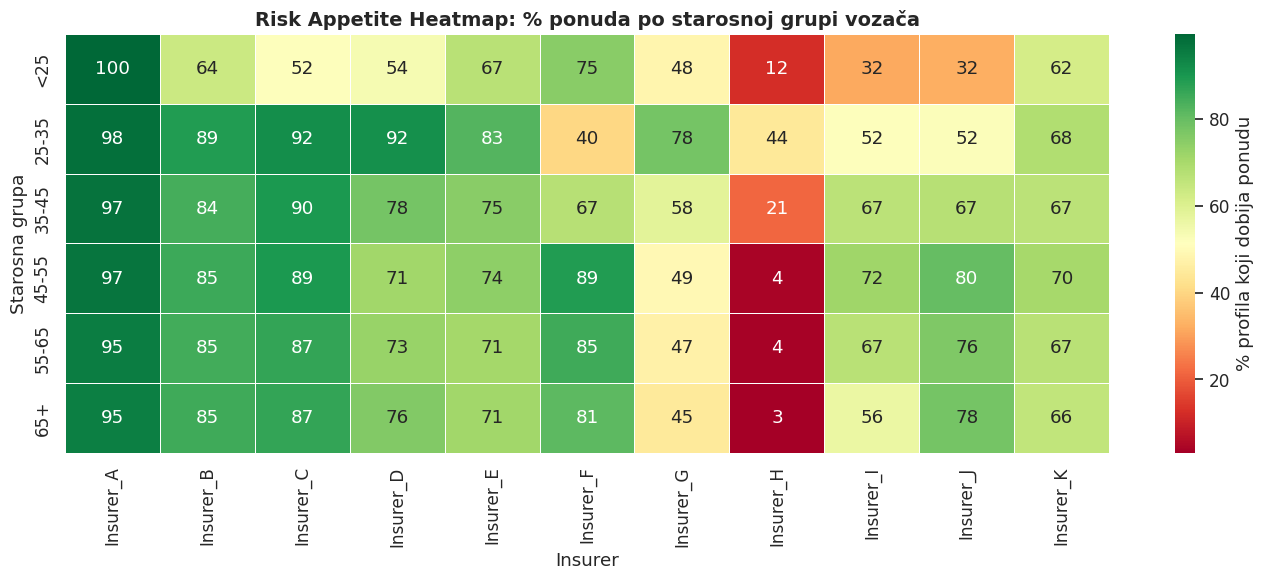

=== ANALIZA 4 — REZULTATI ===

Quote rate po starosnoj grupi (%):
           Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  \
age_group                                                                     
<25             99.6       63.8       51.8       53.8       67.0       75.1   
25-35           97.9       89.0       91.8       91.6       82.6       40.1   
35-45           97.1       84.5       89.7       78.0       74.8       67.5   
45-55           96.6       85.5       89.5       71.0       74.2       89.0   
55-65           95.1       84.5       86.7       72.7       70.7       85.0   
65+             94.8       85.0       86.7       76.2       71.0       81.3   

           Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K  
age_group                                                         
<25             48.1       12.3       31.6       32.2       61.6  
25-35           77.9       44.5       51.9       52.2       68.3  
35-45           58.3       21.4  

In [58]:
# ============================================================
# ANALIZA 4 — Risk Appetite Heatmap (starost vozača)
# ============================================================
has_age = df[df['driver_age'].notna()].copy()

quote_rate_age = pd.DataFrame()
for ins in insurer_cols:
    quote_rate_age[ins.replace('_price', '')] = has_age.groupby(
        'age_group', observed=True)[ins].apply(lambda x: x.notnull().mean() * 100)

plt.figure(figsize=(14, 6))
sns.heatmap(
    quote_rate_age,
    annot=True, fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': '% profila koji dobija ponudu'}
)
plt.title('Risk Appetite Heatmap: % ponuda po starosnoj grupi vozača',
          fontsize=14, fontweight='bold')
plt.xlabel('Insurer')
plt.ylabel('Starosna grupa')
plt.tight_layout()
plt.savefig('04_heatmap_age.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 4 — REZULTATI ===")
print("\nQuote rate po starosnoj grupi (%):")
print(quote_rate_age.round(1))

print("\nNajstroži prema mladima (<25):")
young = quote_rate_age.loc['<25'].sort_values()
for ins, val in young.items():
    print(f"  {ins}: {val:.1f}%")

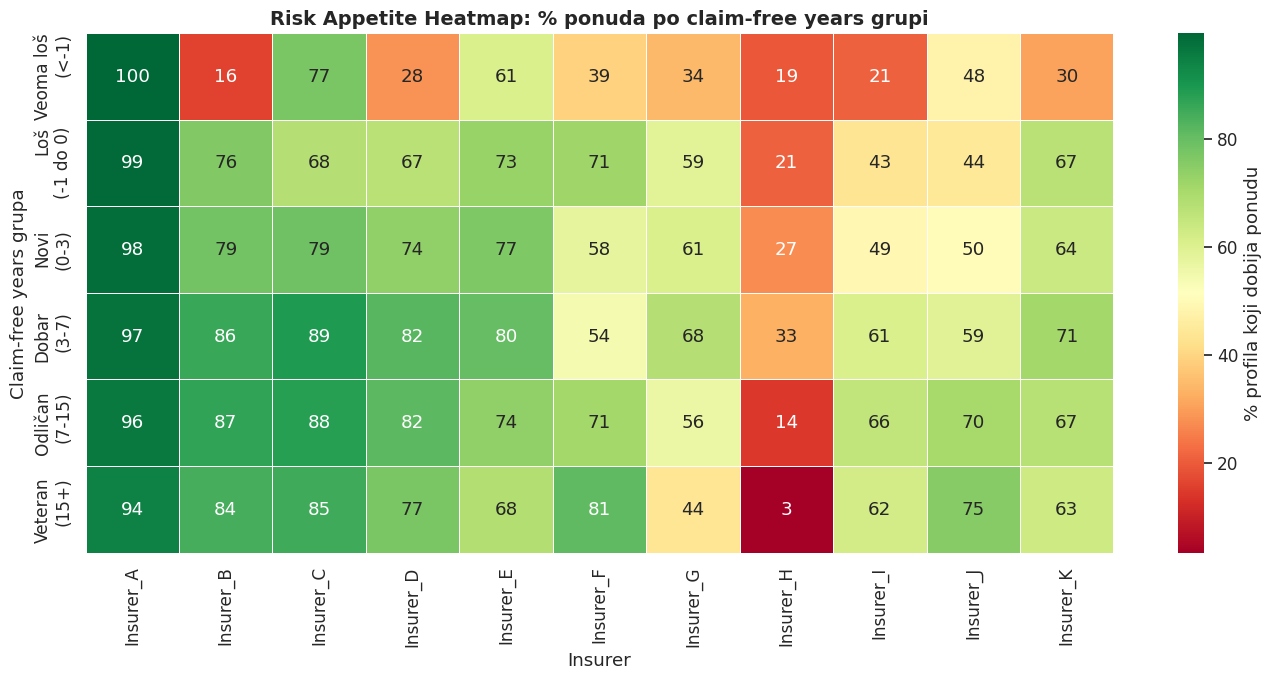

=== ANALIZA 4B — REZULTATI ===

Quote rate po CFR grupi (%):
                  Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  \
cfr_group                                                                 
Veoma loš\n(<-1)       99.6       15.9       77.2       28.1       60.6   
Loš\n(-1 do 0)         99.1       76.0       67.7       67.1       72.8   
Novi\n(0-3)            98.4       78.5       78.8       74.0       76.6   
Dobar\n(3-7)           97.3       86.1       89.3       82.1       80.2   
Odličan\n(7-15)        95.9       87.1       88.1       81.5       73.7   
Veteran\n(15+)         94.0       84.4       85.1       77.2       68.3   

                  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  \
cfr_group                                                                 
Veoma loš\n(<-1)       39.1       34.4       19.2       20.7       47.7   
Loš\n(-1 do 0)         71.4       58.7       20.6       43.2       44.3   
Novi\n(0-3)            57.8       60.5

In [59]:
# ============================================================
# ANALIZA 4B — Risk Appetite Heatmap (claim_free_years)
# ============================================================

# Grupisanje claim_free_years u segmente
df['cfr_group'] = pd.cut(
    df['claim_free_years'],
    bins=[-50, -1, 0, 3, 7, 15, 100],
    labels=['Veoma loš\n(<-1)', 'Loš\n(-1 do 0)', 'Novi\n(0-3)', 
            'Dobar\n(3-7)', 'Odličan\n(7-15)', 'Veteran\n(15+)']
)

quote_rate_cfr = pd.DataFrame()
for ins in insurer_cols:
    quote_rate_cfr[ins.replace('_price', '')] = df.groupby(
        'cfr_group', observed=True)[ins].apply(lambda x: x.notnull().mean() * 100)

plt.figure(figsize=(14, 7))
sns.heatmap(
    quote_rate_cfr,
    annot=True, fmt='.0f',
    cmap='RdYlGn',
    linewidths=0.5,
    cbar_kws={'label': '% profila koji dobija ponudu'}
)
plt.title('Risk Appetite Heatmap: % ponuda po claim-free years grupi',
          fontsize=14, fontweight='bold')
plt.xlabel('Insurer')
plt.ylabel('Claim-free years grupa')
plt.tight_layout()
plt.savefig('04b_heatmap_cfr.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 4B — REZULTATI ===")
print("\nQuote rate po CFR grupi (%):")
print(quote_rate_cfr.round(1))

print("\nNajstroži prema lošim vozačima (Veoma loš):")
bad = quote_rate_cfr.loc['Veoma loš\n(<-1)'].sort_values()
for ins, val in bad.items():
    print(f"  {ins}: {val:.1f}%")

print("\nDistribucija CFR grupa u datasetu:")
print(df['cfr_group'].value_counts().sort_index())

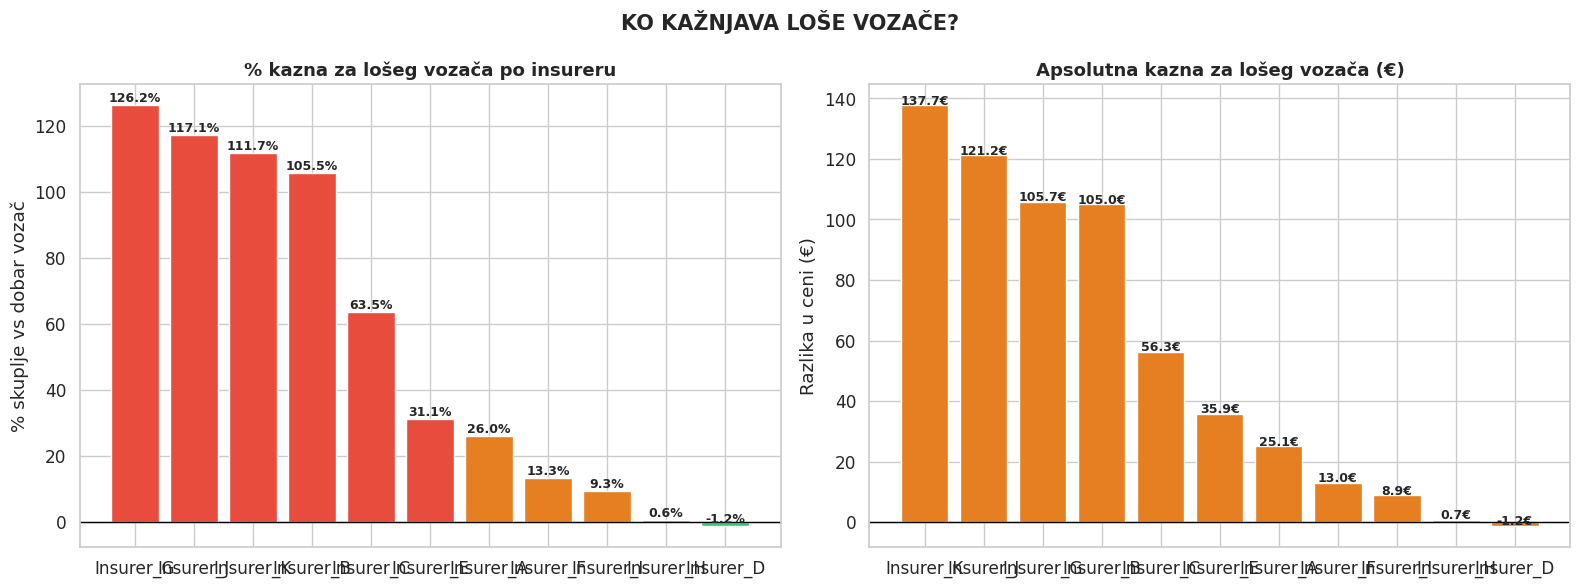

=== ANALIZA 5 — REZULTATI ===
Najviše kažnjava:  Insurer_G (+126.2%)
Najmanje kažnjava: Insurer_D (-1.2%)

Bad drivers u datasetu: 6,092 (1.1%)

Detalji:
  Insurer_G: +126.2%
  Insurer_J: +117.1%
  Insurer_K: +111.7%
  Insurer_B: +105.5%
  Insurer_C: +63.5%
  Insurer_E: +31.1%
  Insurer_A: +26.0%
  Insurer_F: +13.3%
  Insurer_I: +9.3%
  Insurer_H: +0.6%
  Insurer_D: -1.2%


In [60]:
# ============================================================
# ANALIZA 5 — Bad driver penalty (cena za lošeg vozača)
# ============================================================
good = df[df['is_bad_driver'] == 0][insurer_cols].mean()
bad  = df[df['is_bad_driver'] == 1][insurer_cols].mean()
penalty = ((bad - good) / good * 100).sort_values(ascending=False)
penalty.index = [x.replace('_price', '') for x in penalty.index]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Grafik 1: % kazna
colors = ['#e74c3c' if x > 30 else '#e67e22' if x > 0 else '#2ecc71'
          for x in penalty.values]
axes[0].bar(penalty.index, penalty.values, color=colors, edgecolor='white')
axes[0].axhline(0, color='black', linewidth=1)
axes[0].set_title('% kazna za lošeg vozača po insureru', fontsize=13, fontweight='bold')
axes[0].set_ylabel('% skuplje vs dobar vozač')
for i, v in enumerate(penalty.values):
    axes[0].text(i, v + 1, f'{v:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Grafik 2: Apsolutna kazna u €
penalty_abs = (bad - good).sort_values(ascending=False)
penalty_abs.index = [x.replace('_price', '') for x in penalty_abs.index]
axes[1].bar(penalty_abs.index, penalty_abs.values, color='#e67e22', edgecolor='white')
axes[1].axhline(0, color='black', linewidth=1)
axes[1].set_title('Apsolutna kazna za lošeg vozača (€)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Razlika u ceni (€)')
for i, v in enumerate(penalty_abs.values):
    axes[1].text(i, v + 0.3, f'{v:.1f}€', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('KO KAŽNJAVA LOŠE VOZAČE?', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('05_bad_driver_penalty.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 5 — REZULTATI ===")
print(f"Najviše kažnjava:  {penalty.index[0]} (+{penalty.iloc[0]:.1f}%)")
print(f"Najmanje kažnjava: {penalty.index[-1]} ({penalty.iloc[-1]:.1f}%)")
print(f"\nBad drivers u datasetu: {df['is_bad_driver'].sum():,} ({df['is_bad_driver'].mean()*100:.1f}%)")
print(f"\nDetalji:")
for ins, val in penalty.items():
    print(f"  {ins}: {val:+.1f}%")

In [61]:
print("=== INSURER_D — BAD vs GOOD DRIVER ===")
good_d = df[df['is_bad_driver'] == 0]['Insurer_D_price'].mean()
bad_d  = df[df['is_bad_driver'] == 1]['Insurer_D_price'].mean()
print(f"Dobri vozači:  {good_d:.2f}€")
print(f"Loši vozači:   {bad_d:.2f}€")
print(f"Razlika:       {bad_d - good_d:.2f}€")
print(f"Bad driver sample size: {df[df['is_bad_driver']==1]['Insurer_D_price'].notnull().sum()}")

=== INSURER_D — BAD vs GOOD DRIVER ===
Dobri vozači:  98.46€
Loši vozači:   97.25€
Razlika:       -1.21€
Bad driver sample size: 1714
Dobri vozači:  98.46€
Loši vozači:   97.25€
Razlika:       -1.21€
Bad driver sample size: 1714


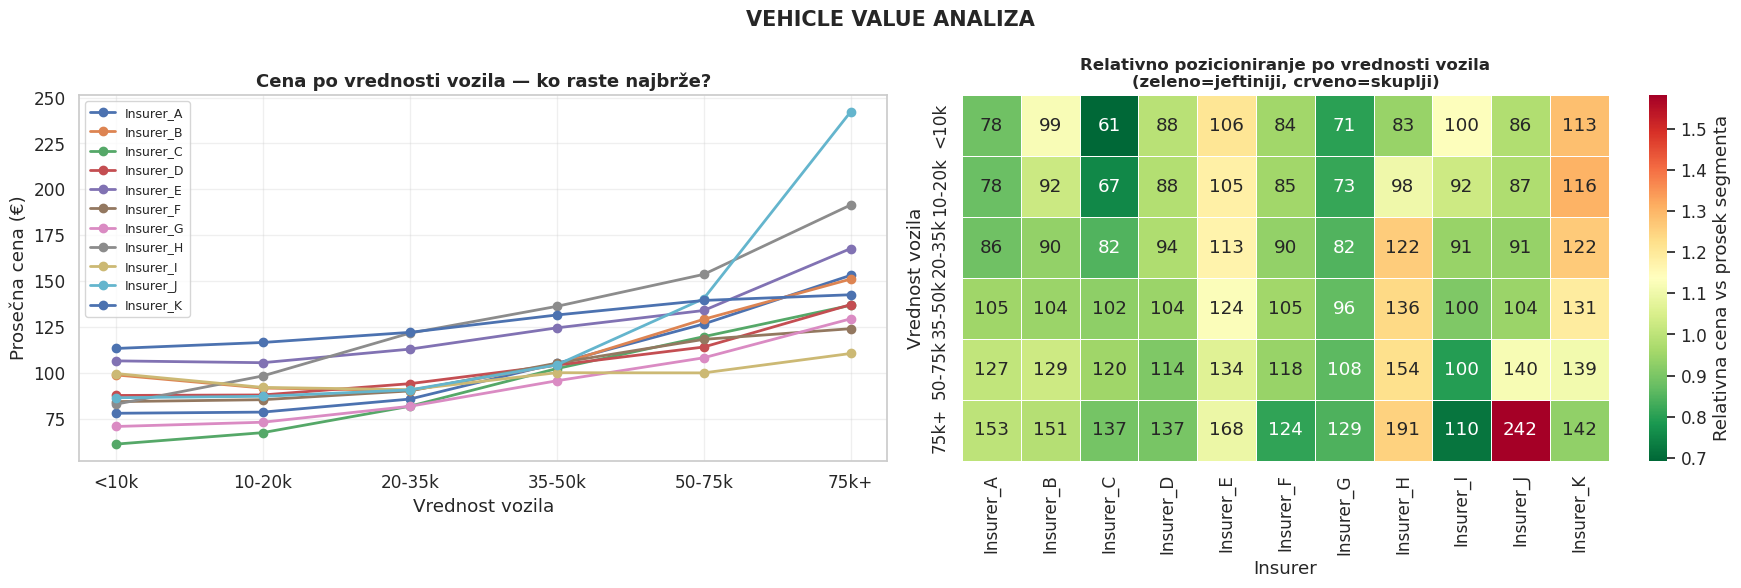

=== ANALIZA 6 — REZULTATI ===

Prosečna cena po vrednosti vozila:
                     Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
vehicle_value_group                                                                                                                         
<10k                      78.0       99.0       61.0       88.0      106.0       84.0       71.0       83.0      100.0       86.0      113.0
10-20k                    78.0       92.0       67.0       88.0      105.0       85.0       73.0       98.0       92.0       87.0      116.0
20-35k                    86.0       90.0       82.0       94.0      113.0       90.0       82.0      122.0       91.0       91.0      122.0
35-50k                   105.0      104.0      102.0      104.0      124.0      105.0       96.0      136.0      100.0      104.0      131.0
50-75k                   127.0      129.0      120.0      114.0      134.0      118.0   

In [62]:
# ============================================================
# ANALIZA 6 — Vehicle value vs cena
# ============================================================
value_prices = df.groupby('vehicle_value_group', observed=True)[insurer_cols].mean()
value_prices.columns = [x.replace('_price', '') for x in value_prices.columns]

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Line chart — ko raste najbrže
for ins in value_prices.columns:
    axes[0].plot(value_prices.index, value_prices[ins],
                 marker='o', linewidth=2, label=ins)
axes[0].set_title('Cena po vrednosti vozila — ko raste najbrže?',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Vrednost vozila')
axes[0].set_ylabel('Prosečna cena (€)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)

# Grafik 2: Heatmap normalizovana po redu
# Pokazuje relativno pozicioniranje unutar svakog value segmenta
value_norm = value_prices.div(value_prices.mean(axis=1), axis=0)
sns.heatmap(
    value_norm,
    annot=value_prices.round(0).astype(int),
    fmt='d',
    cmap='RdYlGn_r',
    linewidths=0.5,
    ax=axes[1],
    cbar_kws={'label': 'Relativna cena vs prosek segmenta'}
)
axes[1].set_title('Relativno pozicioniranje po vrednosti vozila\n(zeleno=jeftiniji, crveno=skuplji)',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Insurer')
axes[1].set_ylabel('Vrednost vozila')

plt.suptitle('VEHICLE VALUE ANALIZA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('06_vehicle_value.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 6 — REZULTATI ===")
print("\nProsečna cena po vrednosti vozila:")
print(value_prices.round(0).to_string())

print("\nNajveći skok cene za luksuzna vozila (75k+ vs <10k):")
jump = ((value_prices.loc['75k+'] - value_prices.loc['<10k']) / 
        value_prices.loc['<10k'] * 100).sort_values(ascending=False)
for ins, val in jump.items():
    print(f"  {ins}: +{val:.0f}%")

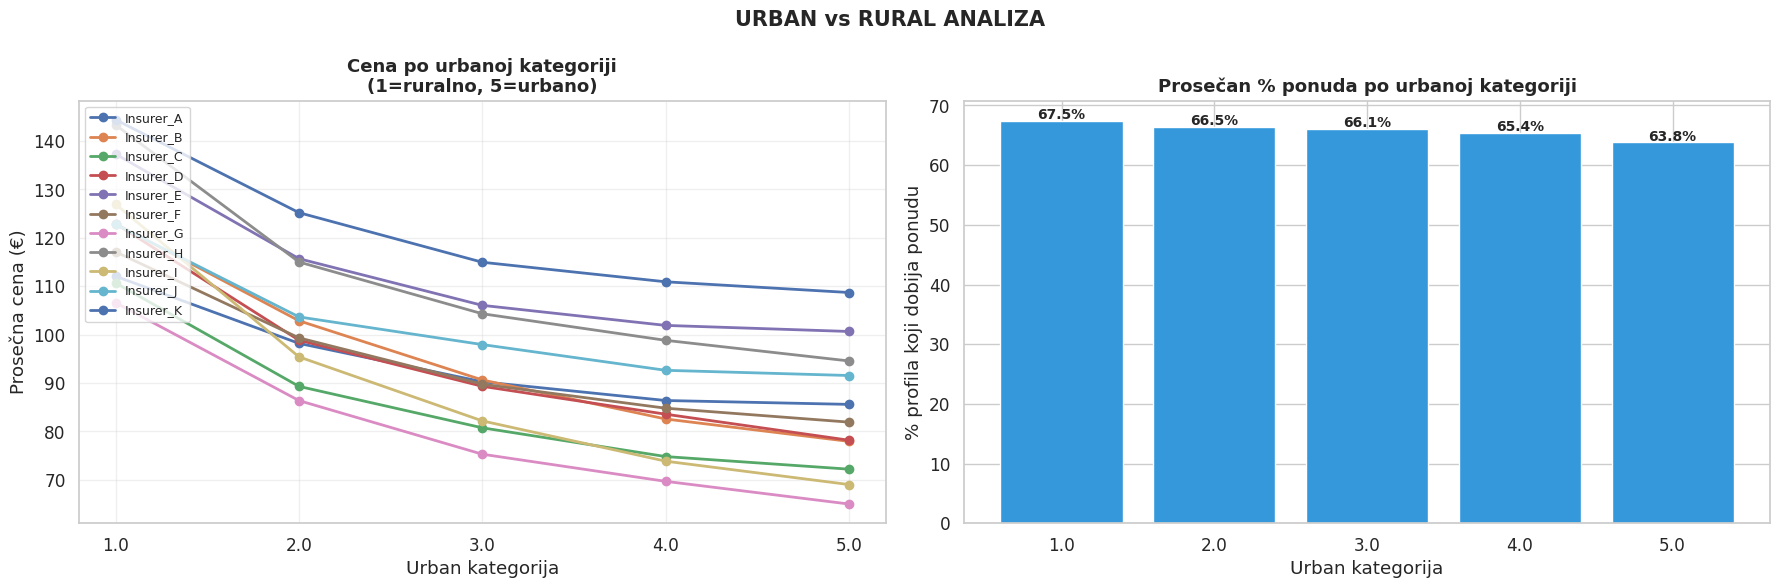

=== ANALIZA 7 — REZULTATI ===

Prosečna cena po urban kategoriji:
                            Insurer_A  Insurer_B  Insurer_C  Insurer_D  Insurer_E  Insurer_F  Insurer_G  Insurer_H  Insurer_I  Insurer_J  Insurer_K
postal_code_urban_category                                                                                                                         
1.0                             112.0      122.9      110.7      122.9      137.3      117.1      106.6      143.3      126.9      122.7      144.4
2.0                              98.2      102.9       89.3       98.8      115.7       99.3       86.4      115.0       95.4      103.6      125.2
3.0                              90.3       90.6       80.7       89.3      106.0       89.8       75.3      104.3       82.2       97.9      114.9
4.0                              86.4       82.6       74.8       83.6      101.9       84.8       69.7       98.8       73.8       92.6      110.9
5.0                              85.6       77

In [63]:
# ============================================================
# ANALIZA 7 — Urban vs Rural
# ============================================================
df['postal_code_urban_category'] = pd.to_numeric(
    df['postal_code_urban_category'], errors='coerce')

urban_prices = df.groupby('postal_code_urban_category', observed=True)[insurer_cols].mean()
urban_prices.columns = [x.replace('_price', '') for x in urban_prices.columns]
urban_prices = urban_prices.dropna()

urban_coverage = df.groupby('postal_code_urban_category', observed=True)[insurer_cols].apply(
    lambda x: x.notnull().mean() * 100).mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Grafik 1: Cena po urban kategoriji
for ins in urban_prices.columns:
    axes[0].plot(urban_prices.index.astype(str), urban_prices[ins],
                 marker='o', linewidth=2, label=ins)
axes[0].set_title('Cena po urbanoj kategoriji\n(1=ruralno, 5=urbano)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Urban kategorija')
axes[0].set_ylabel('Prosečna cena (€)')
axes[0].legend(loc='upper left', fontsize=9)
axes[0].grid(alpha=0.3)

# Grafik 2: Quote rate po urban kategoriji
axes[1].bar(urban_coverage.index.astype(str), urban_coverage.values,
            color='#3498db', edgecolor='white')
axes[1].set_title('Prosečan % ponuda po urbanoj kategoriji',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Urban kategorija')
axes[1].set_ylabel('% profila koji dobija ponudu')
for i, (idx, val) in enumerate(urban_coverage.items()):
    axes[1].text(i, val + 0.3, f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')

plt.suptitle('URBAN vs RURAL ANALIZA', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('07_urban_rural.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 7 — REZULTATI ===")
print("\nProsečna cena po urban kategoriji:")
print(urban_prices.round(1).to_string())

print("\nUrban premium (kat 5 vs kat 1):")
if 5.0 in urban_prices.index and 1.0 in urban_prices.index:
    urban_premium = ((urban_prices.loc[5.0] - urban_prices.loc[1.0]) /
                     urban_prices.loc[1.0] * 100).sort_values(ascending=False)
    for ins, val in urban_premium.items():
        print(f"  {ins}: {val:+.1f}%")

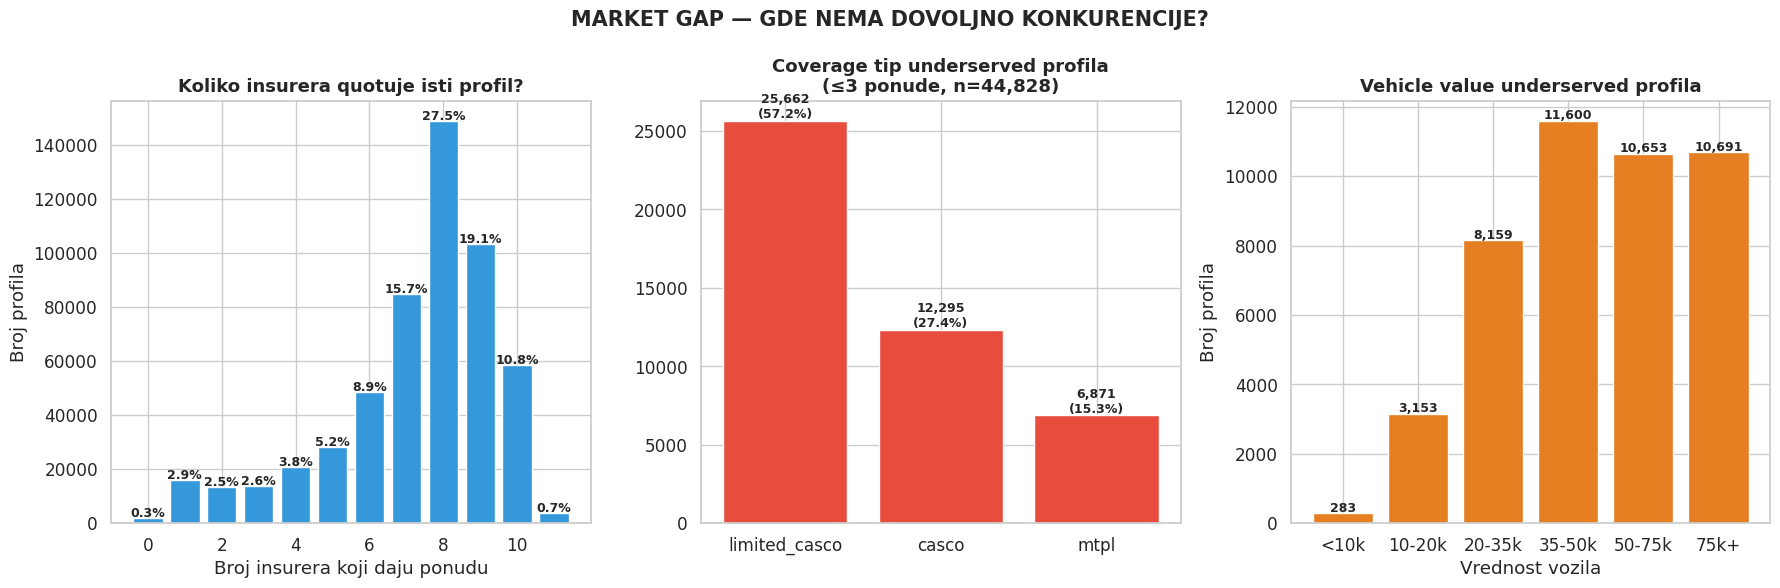

=== ANALIZA 8 — REZULTATI ===

Ukupno profila: 541,292
  1 insurer(a): 15,860 profila (2.9%)
  2 insurer(a): 13,315 profila (2.5%)
  3 insurer(a): 13,895 profila (2.6%)
  4 insurer(a): 20,712 profila (3.8%)

Underserved (≤3): 44,828 (8.3%)

Coverage tip underserved:
coverage
limited_casco    25662
casco            12295
mtpl              6871
Name: count, dtype: int64

Vehicle value underserved:
vehicle_value_group
<10k        283
10-20k     3153
20-35k     8159
35-50k    11600
50-75k    10653
75k+      10691
Name: count, dtype: int64

Urban kategorija underserved:
postal_code_urban_category
1.0     9056
2.0    11391
3.0     8180
4.0     8241
5.0     7923
Name: count, dtype: int64

Prosečna cena underserved profila vs ceo market:
  Insurer_A: market=97€ | underserved=303€ (+212.4%)
  Insurer_B: market=100€ | underserved=156€ (+56.6%)
  Insurer_C: market=89€ | underserved=197€ (+120.3%)
  Insurer_D: market=98€ | underserved=183€ (+86.4%)
  Insurer_E: market=116€ | underserved=253€ (+118

In [64]:
# ============================================================
# ANALIZA 8 — Market Gap (underserved profili)
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Grafik 1: Distribucija broja quotova
quote_dist = df['num_quotes'].value_counts().sort_index()
axes[0].bar(quote_dist.index, quote_dist.values, color='#3498db', edgecolor='white')
axes[0].set_title('Koliko insurera quotuje isti profil?',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Broj insurera koji daju ponudu')
axes[0].set_ylabel('Broj profila')
for idx, val in quote_dist.items():
    axes[0].text(idx, val + 500, f'{val/len(df)*100:.1f}%',
                 ha='center', fontsize=9, fontweight='bold')

# Grafik 2: Coverage tip underserved profila
underserved = df[df['num_quotes'] <= 3]
cov_counts = underserved['coverage'].value_counts()
axes[1].bar(cov_counts.index, cov_counts.values, color='#e74c3c', edgecolor='white')
axes[1].set_title(f'Coverage tip underserved profila\n(≤3 ponude, n={len(underserved):,})',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=0)
for i, (idx, val) in enumerate(cov_counts.items()):
    axes[1].text(i, val + 200, f'{val:,}\n({val/len(underserved)*100:.1f}%)',
                 ha='center', fontsize=9, fontweight='bold')

# Grafik 3: Vehicle value underserved profila
underserved_value = underserved['vehicle_value_group'].value_counts().sort_index()
axes[2].bar(underserved_value.index.astype(str), underserved_value.values,
            color='#e67e22', edgecolor='white')
axes[2].set_title('Vehicle value underserved profila',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Vrednost vozila')
axes[2].set_ylabel('Broj profila')
for i, (idx, val) in enumerate(underserved_value.items()):
    axes[2].text(i, val + 50, f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('MARKET GAP — GDE NEMA DOVOLJNO KONKURENCIJE?',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('08_market_gap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== ANALIZA 8 — REZULTATI ===")
print(f"\nUkupno profila: {len(df):,}")
for n in range(1, 5):
    count = (df['num_quotes'] == n).sum()
    print(f"  {n} insurer(a): {count:,} profila ({count/len(df)*100:.1f}%)")
print(f"\nUnderserved (≤3): {len(underserved):,} ({len(underserved)/len(df)*100:.1f}%)")

print(f"\nCoverage tip underserved:")
print(underserved['coverage'].value_counts())

print(f"\nVehicle value underserved:")
print(underserved['vehicle_value_group'].value_counts().sort_index())

print(f"\nUrban kategorija underserved:")
print(underserved['postal_code_urban_category'].value_counts().sort_index())

print(f"\nProsečna cena underserved profila vs ceo market:")
for ins in insurer_cols:
    market_mean = df[ins].mean()
    under_mean = underserved[ins].mean()
    if pd.notna(under_mean):
        diff = (under_mean - market_mean) / market_mean * 100
        print(f"  {ins.replace('_price','')}: market={market_mean:.0f}€ | underserved={under_mean:.0f}€ ({diff:+.1f}%)")

In [67]:
# ============================================================
# FINAL SUMMARY — Sve u jednom
# ============================================================
print("=" * 65)
print("KOMPLETNI INSIGHTS ZA PREZENTACIJU")
print("=" * 65)

mean_prices = df[insurer_cols].mean().sort_values(ascending=False)
coverage_rate = (df[insurer_cols].notnull().sum() / len(df) * 100)
diff_cols = [f'{ins}_diff_pct' for ins in insurer_cols]
aggression = df[diff_cols].mean().sort_values()
aggression.index = [i.replace('_price_diff_pct', '') for i in aggression.index]

print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PRICING SPREAD
   Najskuplji:   {mean_prices.index[0].replace('_price','')} — {mean_prices.iloc[0]:.0f}€ prosek
   Najjeftiniji: {mean_prices.index[-1].replace('_price','')} — {mean_prices.iloc[-1]:.0f}€ prosek
   Spread:       {(mean_prices.iloc[0]/mean_prices.iloc[-1]-1)*100:.0f}% razlika između najskupljeg i najjeftinijeg

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. TRŽIŠNA SELEKTIVNOST
   Najotvoreniji: Insurer_A — quotuje {coverage_rate['Insurer_A_price']:.1f}% profila, prima SVE vozače
   Najselektivniji: Insurer_H — quotuje samo {coverage_rate['Insurer_H_price']:.1f}% profila
   
   Insurer_H PARADOKS:
   → Odbija 87.7% tržišta
   → Veteranima (15+ CFY) daje samo 3% ponuda
   → Mladima (<25) daje samo 12% ponuda
   → Kada quotuje — naplaćuje premium cene

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. MARKET AGGRESSION
   Discount King: {aggression.index[0]} ({aggression.iloc[0]:.1f}% ispod medijane)
   Premium Player: {aggression.index[-1]} ({aggression.iloc[-1]:.1f}% iznad medijane)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. BAD DRIVER PARADOKS
   Insurer_G: najjeftiniji overall (85€) ali kažnjava loše vozače +126%
   → Koristi pricing kao selekcioni mehanizam
   Insurer_D: ignoriše claims historiju (-1.2% razlika)
   → Sva 1,714 bad driver uzoraka potvrđuju ovo

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. VEHICLE VALUE
   Insurer_J eksplodira na 242€ za luksuzna vozila (+181% vs jeftina)
   Insurer_I flat pricing — samo +11% razlika (slaba segmentacija)
   Sweet spot za novog insurera: 35-75k vozila

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
6. URBAN vs RURAL
   SVi insureri naplaćuju više ruralno — kontraintuitivno!
   Ruralni premium: od -23% (Insurer_A) do -45% (Insurer_I)
   → Ruralni vozači su underserved i preplaćuju

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
7. MARKET GAP
   44,828 profila (8.3%) dobija ≤3 ponude
   Od toga: 57% limited_casco, 27% casco
   Kada insureri ipak quotuju ove profile:
   → Insurer_A naplaćuje 303€ (vs prosek 97€, +212%)
   → Insurer_J naplaćuje 307€ (vs prosek 105€, +193%)
   → Ovo su profili 35-75k vozila, privatna upotreba
   
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
8. PREPORUKA ZA NOVOG INSURERA
   
   TARGETIRAJ:
   → Limited casco segment (57% underserved profila)
   → Vozila 35-75k vrednosti (najveći underserved volumen)
   → Ruralne oblasti (svi overpriceuju ruralno)
   → Loše vozače koje G i B odbijaju (nisko iskorišćen segment)
   
   PRICING STRATEGIJA:
   → Pozicionirati se između G (discount) i K (premium)
   → Ruralni discount manji od konkurencije (competitive advantage)
   → Umerena bad driver kazna — ne 126% kao G, ne 0% kao D
   → Za luksuzna vozila biti ispod J (242€ je outlier)
   
   IZBEGAVAJ:
   → Direktan rat sa Insurer_A (quotuje sve, mass market)
   → MTPL segment (najmanje underserved, 15% gap profila)
""")

KOMPLETNI INSIGHTS ZA PREZENTACIJU

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PRICING SPREAD
   Najskuplji:   Insurer_K — 124€ prosek
   Najjeftiniji: Insurer_G — 85€ prosek
   Spread:       47% razlika između najskupljeg i najjeftinijeg

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. TRŽIŠNA SELEKTIVNOST
   Najotvoreniji: Insurer_A — quotuje 97.4% profila, prima SVE vozače
   Najselektivniji: Insurer_H — quotuje samo 21.0% profila
   
   Insurer_H PARADOKS:
   → Odbija 87.7% tržišta
   → Veteranima (15+ CFY) daje samo 3% ponuda
   → Mladima (<25) daje samo 12% ponuda
   → Kada quotuje — naplaćuje premium cene

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. MARKET AGGRESSION
   Discount King: Insurer_A (-17.3% ispod medijane)
   Premium Player: Insurer_H (53.6% iznad medijane)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. BAD DRIVER PARADOKS
   Insurer_G: najjeftiniji overall (85€) ali kažnja

In [ ]:
data